<a href="https://colab.research.google.com/github/Hassan-Himaz/GM1-Crutch/blob/main/team_stride_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    widgets = None
from IPython.display import display


In [2]:
from pathlib import Path
from collections import deque

twopt_path = Path("hassan_2pt_left_crutch_right_damaged.csv")
threept_path = Path("hassan3pt_left_crutch_left_damaged.csv")
fourpt_path = Path("hassandata1_4pt_left_crutch_right_damaged.csv")
swing_path = Path("hassan_swing.csv")

DATASET_PATHS = {
    "swing": swing_path,
    "2pt": twopt_path,
    "3pt": threept_path,
    "4pt": fourpt_path,
}
DATASET_DIR = Path("Rig_tests_and_analysis")

# Force/r_diff tuning.
MAG_AXIS = "mz_uT"      # choose: mx_uT, my_uT, mz_uT, or mag_norm_uT
USE_ABS_FIELD = False    # use abs(axis) for single-axis force proxy
R0_MM = 25.0
FORCE_SLOPE = 658.7
FORCE_INTERCEPT = -173.5

# Peak-relative release step detector tuning.
STARTUP_ZERO_S = 1.0
BASELINE_WINDOW_SAMPLES = 50
Z_ENTER = 2.0  # Increased from 1.96
RELEASE_FRACTION = 0.3
RELEASE_CONFIRM_MS = 50.0
REFRACTORY_MS = 50.0
POST_RELEASE_BASELINE_SAMPLES = BASELINE_WINDOW_SAMPLES
SUSTAINED_CUTOFF_S = 5.0
MAG_LPF_ALPHA = 0.25
STD_FLOOR = 1.0
MIN_DURATION_S = 0.50
MIN_PEAK_FRAC_OF_MEDIAN = 0.30
MIN_AREA_FRAC_OF_MEDIAN = 0.30

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]

def resolve_capture_path(path):
    path = Path(path)
    if path.exists():
        return path
    analysis_path = DATASET_DIR / path
    if analysis_path.exists():
        return analysis_path
    return path

def load_hassan_capture_csv(path):
    path = resolve_capture_path(path)
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if parts[0] == "seq":
                continue
            if len(parts) != len(RAW_CAPTURE_COLS):
                continue
            try:
                rows.append([float(p) for p in parts])
            except ValueError:
                continue
    if not rows:
        return pd.DataFrame(), path
    df = pd.DataFrame(rows, columns=RAW_CAPTURE_COLS)
    df["seq"] = df["seq"].astype(int)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["accel_mag_g"] = np.sqrt(df["ax_g"]**2 + df["ay_g" ]**2 + df["az_g"]**2)
    df["gyro_mag_dps"] = np.sqrt(df["gx_dps"]**2 + df["gy_dps"]**2 + df["gz_dps"]**2)
    return df, path

def add_force_columns(df):
    df = df.copy()
    df["mag_norm_uT"] = np.sqrt(df["mx_uT"]**2 + df["my_uT"]**2 + df["mz_uT"]**2)
    field = df[MAG_AXIS]
    if USE_ABS_FIELD:
        field = field.abs()
    df["detector_signal_uT"] = field
    df["detector_signal_lpf_uT"] = field.ewm(alpha=MAG_LPF_ALPHA, adjust=False).mean()
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    b0 = startup["detector_signal_lpf_uT"].mean()
    ratio = b0 / df["detector_signal_lpf_uT"]
    ratio = ratio.where((ratio > 0) & np.isfinite(ratio), np.nan)
    df["r_mm"] = R0_MM * np.cbrt(ratio)
    df["r_diff_mm"] = (R0_MM - df["r_mm"]).clip(lower=0.0)
    df["force_n"] = (FORCE_SLOPE * df["r_diff_mm" ] + FORCE_INTERCEPT).clip(lower=0.0)
    return df, b0

def event_area(df, start_s, release_s, baseline):
    event_df = df[(df["time_s"] >= start_s) & (df["time_s"] <= release_s)]
    if len(event_df) < 2:
        return 0.0
    y = (event_df["detector_signal_lpf_uT"] - baseline).clip(lower=0.0)
    return float(np.trapezoid(y, event_df["time_s"]))

def classify_rejections(events_df):
    if events_df.empty:
        events_df["accepted"] = []
        events_df["reject_reason"] = []
        return events_df
    median_peak_amp = events_df["peak_amp"].median()
    median_area = events_df["area"].median()
    accepted = []
    reasons = []
    for row in events_df.itertuples(index=False):
        reason_parts = []
        if row.duration_s < MIN_DURATION_S:
            reason_parts.append("short")
        if median_peak_amp > 0 and row.peak_amp < MIN_PEAK_FRAC_OF_MEDIAN * median_peak_amp:
            reason_parts.append("small_peak")
        if median_area > 0 and row.area < MIN_AREA_FRAC_OF_MEDIAN * median_area:
            reason_parts.append("small_area")
        accepted.append(not reason_parts)
        reasons.append(",".join(reason_parts))
    events_df = events_df.copy()
    events_df["accepted"] = accepted
    events_df["reject_reason"] = reasons
    events_df["median_peak_amp"] = median_peak_amp
    events_df["median_area"] = median_area
    return events_df

def analyze_dataset(dataset_name):
    csv_path = DATASET_PATHS[dataset_name]
    raw_df, csv_path = load_hassan_capture_csv(csv_path)
    if raw_df.empty:
        print(f"No raw 14-column Hassan capture rows in {csv_path}")
        return None, pd.DataFrame(), csv_path, np.nan
    force_df, startup_b0 = add_force_columns(raw_df)
    detected_df, events_df = run_peak_release_pipeline(force_df)
    if len(events_df):
        events_df = events_df.copy()
        events_df.insert(0, "dataset", dataset_name)
        events_df.insert(1, "file", str(csv_path))
    return detected_df, events_df, csv_path, startup_b0

def plot_peak_release_dataset(dataset_name):
    detected_df, events_df, csv_path, startup_b0 = analyze_dataset(dataset_name)
    if detected_df is None:
        return
    accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
    rejected_df = events_df[~events_df["accepted"]] if len(events_df) else events_df
    steps = int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0
    sustained = int((accepted_df["kind"] == "sustained").sum()) if len(accepted_df) else 0
    display(pd.Series({
        "dataset": dataset_name,
        "file": str(csv_path),
        "rows": len(detected_df),
        "duration_s": detected_df["time_s"].iloc[-1],
        "mag_axis_for_detector": MAG_AXIS,
        "use_abs_field": USE_ABS_FIELD,
        "startup_b0_uT": startup_b0,
        "candidates": len(events_df),
        "accepted": len(accepted_df),
        "rejected": len(rejected_df),
        "steps": steps,
        "sustained": sustained,
        "max_z": detected_df["z_score"].max(),
        "max_r_diff_mm": detected_df["r_diff_mm"].max(),
        "max_force_n": detected_df["force_n"].max(),
    }, name="peak-release summary"))
    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_df[cols] if len(events_df) else events_df)
    fig, axs = plt.subplots(17, 1, figsize=(13, 42), sharex=True)
    axs[0].plot(detected_df["time_s"], detected_df["mz_uT"], lw=0.8, label="mz_uT")
    axs[0].set_ylabel("mz (uT)")
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_uT"], lw=0.45, alpha=0.35, label=f"{MAG_AXIS} raw")
    axs[1].plot(detected_df["time_s"], detected_df["detector_signal_lpf_uT"], lw=1.0, label=f"filtered {MAG_AXIS}")
    axs[1].plot(detected_df["time_s"], detected_df["baseline_mean"], lw=1.1, label="baseline")
    axs[1].plot(detected_df["time_s"], detected_df["release_level"], lw=1.0, ls="--", color="C3", label=f"{RELEASE_FRACTION:.0%} release level")
    axs[1].set_ylabel("detector (uT)")
    axs[1].legend(loc="upper right")
    axs[1].grid(True, alpha=0.3)
    axs[2].plot(detected_df["time_s"], detected_df["z_score"], lw=0.9, color="C4")
    axs[2].axhline(Z_ENTER, color="C3", ls="--", lw=1.0, label="z entry (hard)")
    if 'Z_ENTER_SOFT' in globals():
        axs[2].axhline(Z_ENTER_SOFT, color="C1", ls=":", lw=1.0, label="z entry (soft)")
    axs[2].set_ylabel("z")
    axs[2].legend(loc="upper right")
    axs[2].grid(True, alpha=0.3)
    # Diagnostic Corroboration Subplot
    if "accel_corr" in detected_df.columns:
        axs[3].fill_between(detected_df["time_s"], 0, detected_df["accel_corr"], color="C2", alpha=0.2, label="Accel Corr")
        axs[3].fill_between(detected_df["time_s"], 0, detected_df["gyro_corr_flag"], color="C1", alpha=0.2, label="Gyro Corr")
        axs[3].plot(detected_df["time_s"], detected_df["roll_unstable"]*(-1), color="C3", label="Roll Holdoff")
    axs[3].set_ylabel("Diagnostics")
    axs[3].legend(loc="upper right")
    axs[3].grid(True, alpha=0.3)
    # Original subplots shifted down by 1
    axs[4].plot(detected_df["time_s"], detected_df["accel_mag_g"], lw=0.85, color="C0")
    axs[4].set_ylabel("accel mag (g)")
    axs[5].plot(detected_df["time_s"], detected_df["ax_g"], lw=0.85, color="C1")
    axs[5].set_ylabel("ax (g)")
    axs[6].plot(detected_df["time_s"], detected_df["ay_g"], lw=0.85, color="C2")
    axs[6].set_ylabel("ay (g)")
    axs[7].plot(detected_df["time_s"], detected_df["az_g"], lw=0.85, color="C9")
    axs[7].set_ylabel("az (g)")
    axs[8].plot(detected_df["time_s"], detected_df["gyro_mag_dps"], lw=0.85, color="C8")
    axs[8].set_ylabel("gyro mag (dps)")
    axs[9].plot(detected_df["time_s"], detected_df["gx_dps"], lw=0.85, color="C0")
    axs[9].set_ylabel("gx (dps)")
    axs[10].plot(detected_df["time_s"], detected_df["gy_dps"], lw=0.85, color="C1")
    axs[10].set_ylabel("gy (dps)")
    axs[11].plot(detected_df["time_s"], detected_df["gz_dps"], lw=0.85, color="C2")
    axs[11].set_ylabel("gz (dps)")
    axs[12].plot(detected_df["time_s"], detected_df["roll_deg"], lw=0.85, color="C6")
    axs[12].set_ylabel("roll (deg)")
    axs[13].plot(detected_df["time_s"], detected_df["pitch_deg"], lw=0.85, color="C7")
    axs[13].set_ylabel("pitch (deg)")
    axs[14].plot(detected_df["time_s"], detected_df["yaw_deg"], lw=0.85, color="C3")
    axs[14].set_ylabel("yaw (deg)")
    axs[15].plot(detected_df["time_s"], detected_df["r_diff_mm"], lw=0.9, color="C2")
    axs[15].set_ylabel("r_diff (mm)")
    axs[16].plot(detected_df["time_s"], detected_df["force_n"], lw=0.9, color="C5")
    axs[16].set_ylabel("force estimate (N)")
    for event in events_df.to_dict("records"):
        color = "0.5" if not event["accepted"] else ("C2" if event["kind"] == "step" else "C1")
        alpha = 0.10 if not event["accepted"] else 0.16
        for ax in axs: ax.axvspan(event["start_s"], event["confirm_s"], color=color, alpha=alpha)
    plt.tight_layout(); plt.show()

def compare_peak_release_datasets():
    rows = []; all_events = []
    for dataset_name in DATASET_PATHS:
        detected_df, events_df, csv_path, _ = analyze_dataset(dataset_name)
        if detected_df is None: continue
        accepted_df = events_df[events_df["accepted"]] if len(events_df) else events_df
        rows.append({"dataset": dataset_name, "file": str(csv_path), "candidates": len(events_df), "accepted": len(accepted_df),
                     "steps": int((accepted_df["kind"] == "step").sum()) if len(accepted_df) else 0,
                     "max_z": round(float(detected_df["z_score"].max()), 1),
                     "max_force_n": round(float(detected_df["force_n"].max()), 1)})
        all_events.append(events_df)
    summary_df = pd.DataFrame(rows); display(summary_df)
    events_table = pd.concat(all_events, ignore_index=True) if all_events else pd.DataFrame()
    cols = ["dataset", "start_s", "release_s", "duration_s", "kind", "accepted", "reject_reason", "peak_amp", "area"]
    display(events_table[cols] if len(events_table) else events_table)

In [10]:
def run_peak_release_pipeline(df):
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR
        return mean, max(std, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    states = []
    baseline_means = []
    baseline_stds = []
    z_scores = []
    release_levels = []
    peak_values = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing")
            baseline_means.append(baseline_mean)
            baseline_stds.append(baseline_std)
            z_scores.append(0.0)
            release_levels.append(np.nan)
            peak_values.append(np.nan)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            if can_start and z >= Z_ENTER:
                state = "loaded"
                load_start_t = t
                release_candidate_t = None
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan)
            peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b <= release_level:
                state = "releasing"
                release_candidate_t = t

            release_levels.append(release_level)
            peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)

            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                duration_s = release_t - load_start_t
                kind = "step" if duration_s < SUSTAINED_CUTOFF_S else "sustained"
                peak_amp = peak_signal - baseline_at_entry
                area = event_area(df, load_start_t, release_t, baseline_at_entry)
                events.append({
                    "start_s": load_start_t,
                    "release_s": release_t,
                    "confirm_s": t,
                    "duration_s": duration_s,
                    "kind": kind,
                    "baseline_at_entry": baseline_at_entry,
                    "peak_signal_uT": peak_signal,
                    "peak_amp": peak_amp,
                    "area": area,
                    "release_level": release_level,
                })

                # Start the next unloaded baseline at the detected release point,
                # not at the later confirmation point.
                release_samples = df.loc[
                    (df["time_s"] >= release_t) & (df["time_s"] <= t),
                    "detector_signal_lpf_uT",
                ]
                baseline_window.clear()
                for sample in release_samples:
                    baseline_window.append(sample)
                baseline_mean, baseline_std = window_stats(baseline_window)
                post_release_baseline_samples = max(
                    POST_RELEASE_BASELINE_SAMPLES - len(release_samples),
                    0,
                )

                state = "idle"
                load_start_t = None
                release_candidate_t = None
                last_release_t = t
                baseline_at_entry = None
                peak_signal = None
                release_level = np.nan

            release_levels.append(release_level)
            peak_values.append(peak_signal if peak_signal is not None else np.nan)

        states.append(state)
        baseline_means.append(baseline_mean)
        baseline_stds.append(baseline_std)
        z_scores.append(z)

    out = df.copy()
    out["state"] = states
    out["baseline_mean"] = baseline_means
    out["baseline_std"] = baseline_stds
    out["z_score"] = z_scores
    out["release_level"] = release_levels
    out["peak_signal_uT"] = peak_values
    events_df = classify_rejections(pd.DataFrame(events))
    return out, events_df

In [3]:
def run_rdiff_pipeline(df):
    """New Pipeline: Uses physical r_diff_mm (displacement) for stance detection."""
    state = "idle"; load_start_t = None; last_release_t = -1e9; peak_r = 0.0; events = []

    for row in df.itertuples(index=False):
        t, r = row.time_s, row.r_diff_mm

        if state == "idle":
            if r >= R_DIFF_ENTER_MM and (t - last_release_t) * 1000.0 >= REFRACTORY_MS:
                state = "loaded"; load_start_t = t; peak_r = r
        elif state == "loaded":
            if r > peak_r: peak_r = r
            if r <= (peak_r * RELEASE_FRACTION):
                duration = t - load_start_t
                events.append({
                    "start_s": load_start_t, "release_s": t, "duration_s": duration,
                    "kind": "step" if duration < SUSTAINED_CUTOFF_S else "sustained",
                    "peak_amp": peak_r,
                    "area": event_area(df, load_start_t, t, 0.0)
                })
                state = "idle"; last_release_t = t

    return df, classify_rejections(pd.DataFrame(events))

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
def plot_multi_channel_fft(dataset_name, window_s=1.0, step_s=0.1, max_freq=10.0):
    """
    Calculates sliding FFTs for an expanded set of gait channels including
    raw magnetic axes and vector magnitudes.
    """
    detected_df, events_df, _, _ = analyze_dataset(dataset_name)
    if detected_df is None:
        return

    # Expanded channel list
    channels = [
        ('ax_g', 'Accel X (g)'), ('ay_g', 'Accel Y (g)'), ('az_g', 'Accel Z (g)'),
        ('accel_mag_g', 'Accel Mag (g)'),
        ('gx_dps', 'Gyro X (dps)'), ('gy_dps', 'Gyro Y (dps)'), ('gz_dps', 'Gyro Z (dps)'),
        ('gyro_mag_dps', 'Gyro Mag (dps)'),
        ('mx_uT', 'Mag X (uT)'), ('my_uT', 'Mag Y (uT)'), ('mz_uT', 'Mag Z (uT)'),
        ('roll_deg', 'Roll (deg)'), ('pitch_deg', 'Pitch (deg)'), ('yaw_deg', 'Yaw (deg)'),
        ('force_n', 'Force (N)')
    ]

    time = detected_df['time_s'].values
    dt = np.median(np.diff(time))
    fs = 1.0 / dt
    nyquist = fs / 2.0
    display_max_freq = max_freq if max_freq is not None else nyquist

    window_size = int(window_s * fs)
    step_size = int(step_s * fs)

    num_channels = len(channels)
    fig, axs = plt.subplots(num_channels, 1, figsize=(13, 2.5 * num_channels), sharex=True)

    for idx, (col, label) in enumerate(channels):
        if col not in detected_df.columns:
            axs[idx].text(0.5, 0.5, f'Column {col} missing', ha='center')
            continue

        signal = detected_df[col].values
        fft_results = []
        window_times = []

        for i in range(0, len(signal) - window_size, step_size):
            window = signal[i : i + window_size]
            window = window - np.mean(window) # Detrend

            fft_vals = np.abs(np.fft.rfft(window))
            freqs = np.fft.rfftfreq(window_size, d=dt)

            fft_results.append(fft_vals)
            window_times.append(time[i] + window_s/2.0)

        fft_results = np.array(fft_results).T
        freq_mask = freqs <= display_max_freq

        im = axs[idx].pcolormesh(window_times, freqs[freq_mask], fft_results[freq_mask, :],
                               shading='gouraud', cmap='magma')

        # Overlay step boundaries
        if not events_df.empty:
            for event in events_df.to_dict('records'):
                color = '0.5' if not event['accepted'] else ('C2' if event['kind'] == 'step' else 'C1')
                axs[idx].axvspan(event['start_s'], event['confirm_s'], color=color, alpha=0.15)

        axs[idx].set_ylabel(f'{label}\nHz')
        axs[idx].set_ylim(0, display_max_freq)
        plt.colorbar(im, ax=axs[idx], label='Amp')

    axs[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Expanded Multi-Channel Spectral Analysis: {dataset_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

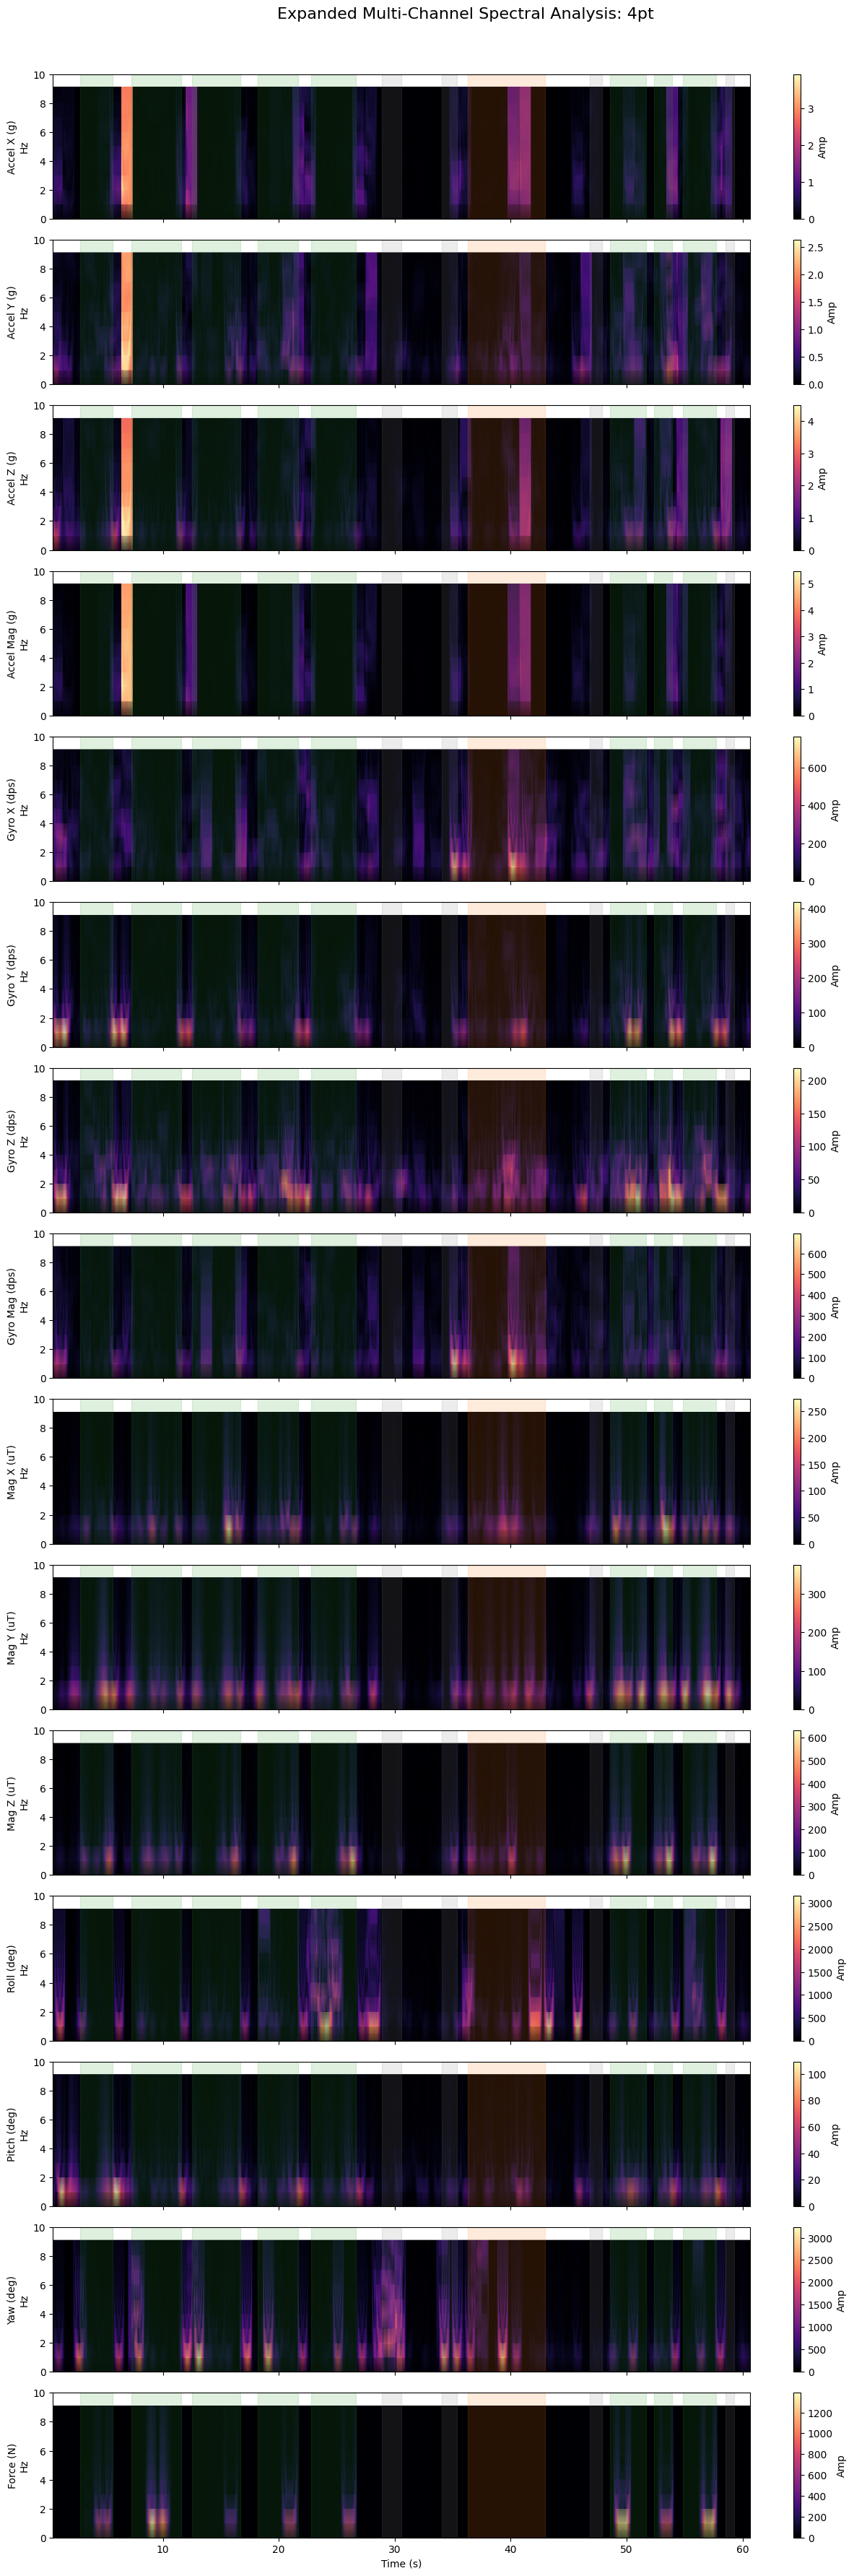

In [9]:
# Run the updated expanded analysis
plot_multi_channel_fft("4pt", window_s=1.0, step_s=0.05, max_freq=10.0)

,dataset,file,candidates,accepted,steps,max_z,max_force_n
0,swing,hassan_swing.csv,13,13,13,22.5,647.8
1,2pt,hassan_2pt_left_crutch_right_damaged.csv,10,10,10,58.1,473.7
2,3pt,hassan3pt_left_crutch_left_damaged.csv,16,15,15,11.6,164.5
3,4pt,hassandata1_4pt_left_crutch_right_damaged.csv,13,9,9,70.6,171.4


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,swing,1.683,3.234,1.551,step,True,,77.849923,52.721076
1,swing,3.861,4.719,0.858,step,True,,71.825967,34.615973
2,swing,6.138,6.798,0.660,step,True,,68.303506,29.237019
3,swing,8.184,8.976,0.792,step,True,,80.680807,35.769629
4,swing,10.560,11.187,0.627,step,True,,68.867103,26.297243
5,swing,12.441,13.530,1.089,step,True,,74.539593,40.647301
6,swing,14.421,17.061,2.640,step,True,,108.038349,159.098424
7,swing,17.754,18.612,0.858,step,True,,61.038100,30.454897
8,swing,19.470,20.031,0.561,step,True,,69.011197,25.072018
9,swing,21.681,22.209,0.528,step,True,,56.604370,20.019092


,peak-release summary
dataset,4pt
file,hassandata1_4pt_left_crutch_right_damaged.csv
rows,1853
duration_s,61.116
mag_axis_for_detector,mz_uT
use_abs_field,False
startup_b0_uT,765.702055
candidates,13
accepted,9
rejected,4


,dataset,start_s,release_s,duration_s,kind,accepted,reject_reason,peak_amp,area
0,4pt,3.102,5.511,2.409,step,True,,36.379864,58.510128
1,4pt,8.019,11.484,3.465,step,True,,68.474034,132.395851
2,4pt,12.606,16.599,3.993,step,True,,50.895880,80.129576
3,4pt,18.150,21.615,3.465,step,True,,57.396107,82.432511
4,4pt,22.770,26.565,3.795,step,True,,56.065326,62.239311
5,4pt,28.809,30.657,1.848,step,False,"small_peak,small_area",11.673169,16.555293
6,4pt,34.254,35.244,0.990,step,False,small_area,17.307989,9.998250
7,4pt,36.333,40.491,4.158,step,True,,47.721631,143.236772
8,4pt,41.547,42.702,1.155,step,False,"small_peak,small_area",11.500456,9.379905
9,4pt,46.827,47.784,0.957,step,False,"small_peak,small_area",4.904823,3.263041


/tmp/ipykernel_3326/3937092588.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[3].legend(loc="upper right")


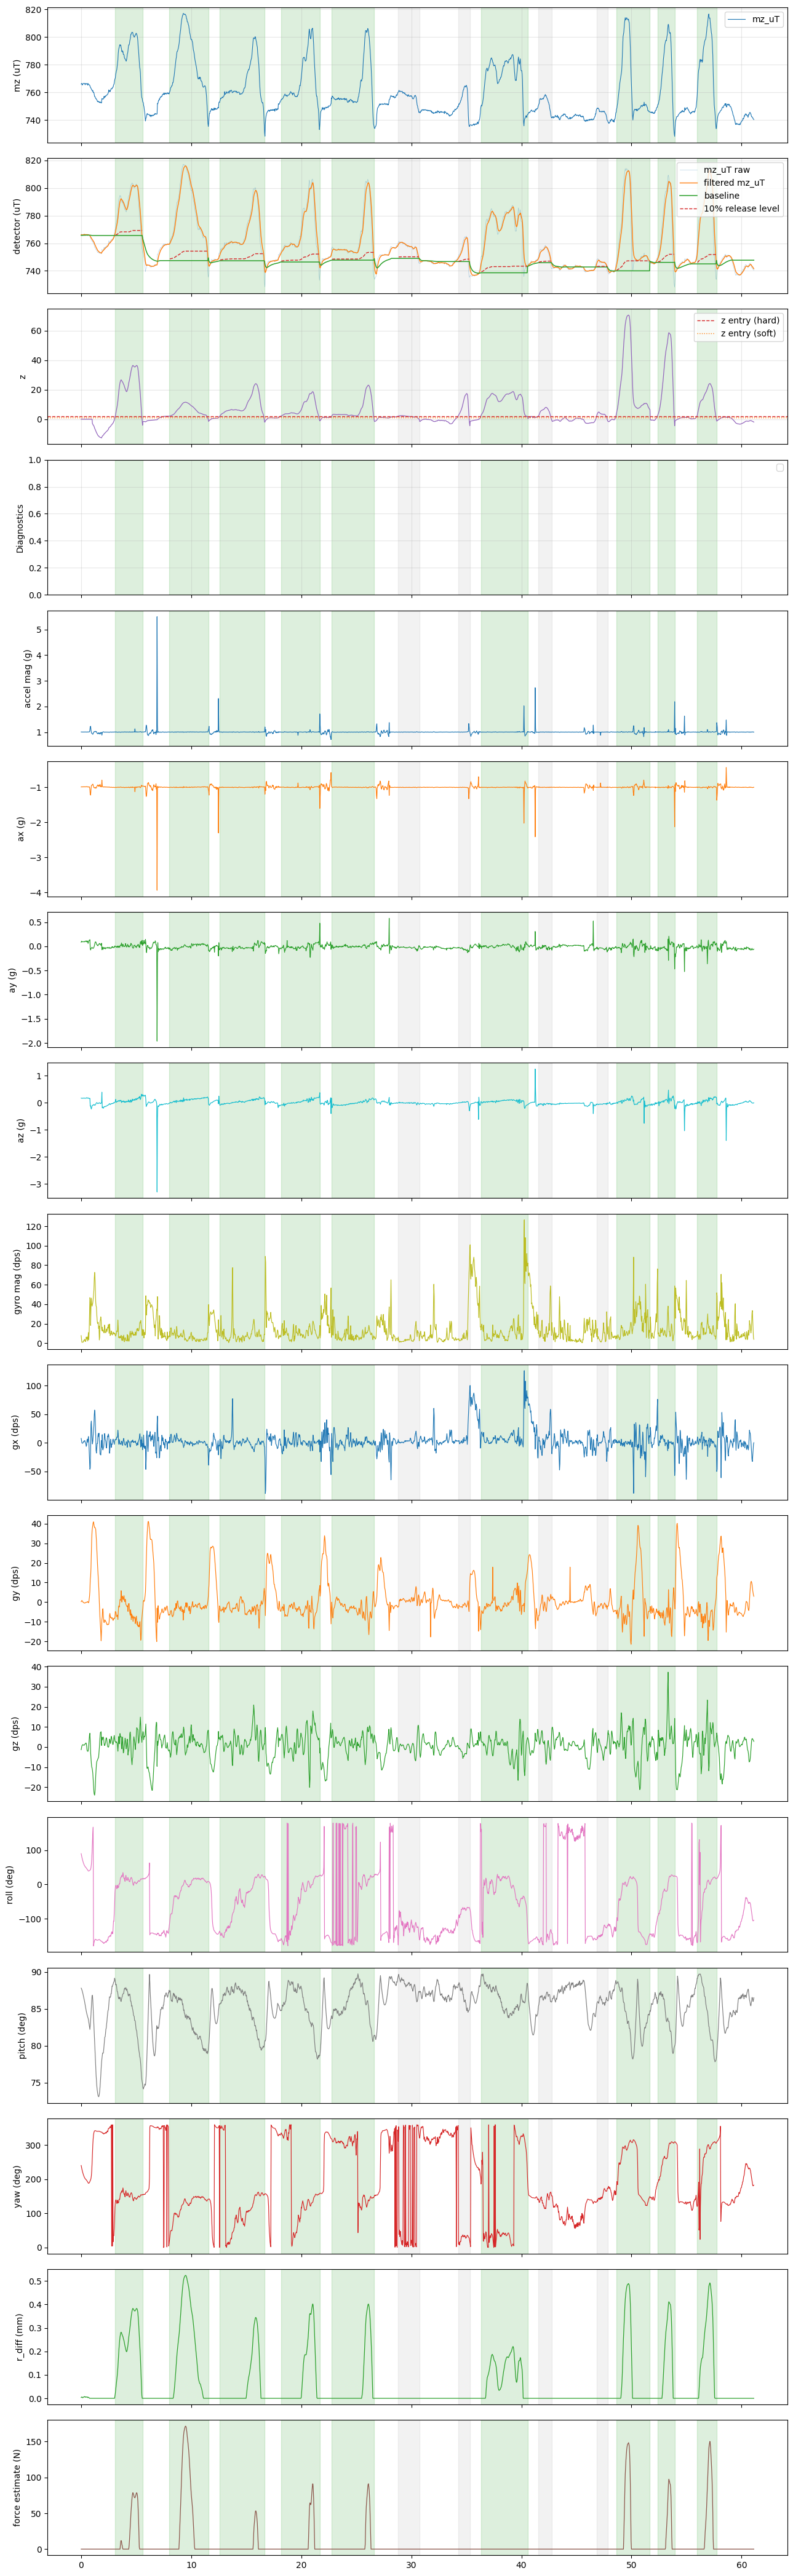

In [28]:
# Compare across all datasets using updated Z thresholds (Soft=1.0, Hard=2.0)
compare_peak_release_datasets()

# Visualize the 4pt dataset with diagnostic flags
plot_peak_release_dataset("4pt")

In [5]:
def corroborated_pipeline(df, z_soft=1.0, z_hard=2.0, corr_window_ms=80.0):
    """
    Enhanced pipeline using Soft Entry logic.
    A step starts if Z >= z_soft AND secondary sensors (Accel/Gyro) corroborate.
    Falls back to z_hard if no corroboration is found but signal is very strong.
    """
    # Re-using the logic from run_peak_release_pipeline but adding corroboration triggers
    startup = df[df["time_s"] <= STARTUP_ZERO_S]
    startup_std_floor = max(startup["detector_signal_lpf_uT"].std(ddof=1), STD_FLOOR)
    baseline_window = deque(startup["detector_signal_lpf_uT"].tail(BASELINE_WINDOW_SAMPLES), maxlen=BASELINE_WINDOW_SAMPLES)

    def window_stats(window):
        vals = pd.Series(list(window), dtype="float64")
        return vals.mean(), max(vals.std(ddof=1) if len(vals) > 1 else STD_FLOOR, startup_std_floor)

    def update_rolling_baseline(window, b):
        window.append(b)
        return window_stats(window)

    baseline_mean, baseline_std = window_stats(baseline_window)
    state = "idle"
    load_start_t = None
    release_candidate_t = None
    last_release_t = -1e9
    post_release_baseline_samples = 0
    baseline_at_entry = None
    peak_signal = None
    release_level = np.nan
    events = []

    # Arrays for column output
    states, baseline_means, z_scores, release_levels, peak_values = [], [], [], [], []
    corroborated_flags = []

    for row in df.itertuples(index=False):
        t = row.time_s
        b = row.detector_signal_lpf_uT

        # Secondary triggers for corroboration
        # Look for a sharp dip in AZ (impact) or high gyro activity
        accel_dip = row.az_g < -0.15
        gyro_active = (abs(row.gx_dps) > 20) or (abs(row.gy_dps) > 20)
        is_corroborated = accel_dip or gyro_active

        if t <= STARTUP_ZERO_S:
            baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
            states.append("zeroing"); baseline_means.append(baseline_mean); z_scores.append(0.0)
            release_levels.append(np.nan); peak_values.append(np.nan); corroborated_flags.append(False)
            continue

        z = (b - baseline_mean) / max(baseline_std, STD_FLOOR)

        if state == "idle":
            can_start = (t - last_release_t) * 1000.0 >= REFRACTORY_MS
            # Soft Entry Logic: Trigger on soft Z but require corroboration,
            # OR trigger immediately on Hard Z.
            if can_start and (z >= z_hard or (z >= z_soft and is_corroborated)):
                state = "loaded"
                load_start_t = t
                baseline_at_entry = baseline_mean
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
                post_release_baseline_samples = 0
            elif post_release_baseline_samples > 0:
                baseline_mean, baseline_std = update_rolling_baseline(baseline_window, b)
                post_release_baseline_samples -= 1
            release_levels.append(np.nan); peak_values.append(np.nan)

        elif state == "loaded":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            if b <= release_level:
                state = "releasing"
                release_candidate_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        elif state == "releasing":
            if b > peak_signal:
                peak_signal = b
                release_level = baseline_at_entry + RELEASE_FRACTION * (peak_signal - baseline_at_entry)
            if b > release_level:
                state = "loaded"
                release_candidate_t = None
            elif (t - release_candidate_t) * 1000.0 >= RELEASE_CONFIRM_MS:
                release_t = release_candidate_t
                events.append({
                    "start_s": load_start_t, "release_s": release_t, "confirm_s": t,
                    "duration_s": release_t - load_start_t,
                    "kind": "step" if (release_t - load_start_t) < SUSTAINED_CUTOFF_S else "sustained",
                    "peak_amp": peak_signal - baseline_at_entry,
                    "area": event_area(df, load_start_t, release_t, baseline_at_entry)
                })
                # Reset baseline at release point
                release_samples = df.loc[(df["time_s"] >= release_t) & (df["time_s"] <= t), "detector_signal_lpf_uT"]
                baseline_window.clear()
                for s in release_samples: baseline_window.append(s)
                baseline_mean, baseline_std = window_stats(baseline_window)
                post_release_baseline_samples = max(POST_RELEASE_BASELINE_SAMPLES - len(release_samples), 0)
                state = "idle"; last_release_t = t
            release_levels.append(release_level); peak_values.append(peak_signal)

        states.append(state); baseline_means.append(baseline_mean); z_scores.append(z); corroborated_flags.append(is_corroborated)

    out = df.copy()
    out["state"] = states
    out["z_score"] = z_scores
    out["is_corroborated"] = corroborated_flags
    return out, classify_rejections(pd.DataFrame(events))

# Exporting to Better Format

In [9]:
merged_dfs = []

for gait_name in DATASET_PATHS.keys():
    # 1. Run the existing analysis pipeline for each file
    detected_df, events_df, _, _ = analyze_dataset(gait_name)

    if detected_df is None or detected_df.empty:
        continue

    # 2. Add labeling
    temp_df = detected_df.copy()
    temp_df['gait_type'] = gait_name

    # 3. Create 'is_stance' column (the green/orange spans)
    # Default to False
    temp_df['is_stance'] = False

    if not events_df.empty:
        # Only consider accepted steps/sustained events
        accepted_events = events_df[events_df['accepted'] == True]

        for _, event in accepted_events.iterrows():
            # Mark rows within the start and release times as stance
            mask = (temp_df['time_s'] >= event['start_s']) & (temp_df['time_s'] <= event['release_s'])
            temp_df.loc[mask, 'is_stance'] = True

    merged_dfs.append(temp_df)

# Combine all into one master DataFrame
master_df = pd.concat(merged_dfs, ignore_index=True)

# Reorder columns to put labels at the front for readability
cols = ['gait_type', 'time_s', 'is_stance', 'force_n'] + [c for c in master_df.columns if c not in ['gait_type', 'time_s', 'is_stance', 'force_n']]
master_df = master_df[cols]

# Save to CSV
output_filename = "merged_gait_analysis.csv"
master_df.to_csv(output_filename, index=False)

print(f"Success! Merged {len(merged_dfs)} datasets.")
print(f"Total rows: {len(master_df)}")
print(f"File saved as: {output_filename}")

# Display a preview
display(master_df.head())
display(master_df['gait_type'].value_counts())

NameError: name 'run_peak_release_pipeline' is not defined

# Sina and Thomas Data Analysis

## Add the Force Measurements

In [6]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

subject_registry = {
    "hassan_swing.csv": ("Hassan", "swing"),
    "hassan_2pt_left_crutch_right_damaged.csv": ("Hassan", "2pt"),
    "hassan3pt_left_crutch_left_damaged.csv": ("Hassan", "3pt"),
    "hassandata1_4pt_left_crutch_right_damaged.csv": ("Hassan", "4pt"),
    "thomas_4pt.csv": ("Thomas", "4pt"),
    "2pointgatethomas.csv": ("Thomas", "2pt"),
    "3pointthomas4.csv": ("Thomas", "3pt"),
    "swingthroughthomas2.csv": ("Thomas", "swing"),
    "sina_4pt.csv": ("Sina", "4pt"),
    "2pointgatesina5.csv": ("Sina", "2pt"),
    "3pointsina3.csv": ("Sina", "3pt"),
    "swingthroughsina1.csv": ("Sina", "swing"),
    "tgfall.csv": ("Thomas", "fall"),
    "tgfall2.csv": ("Thomas", "fall"),
}

all_processed_data = []

for filename, (person, gait) in subject_registry.items():
    path_obj = Path(filename)
    if not path_obj.exists(): continue

    print(f"Processing {person} - {gait} ({filename}) using Corroborated Method...")

    # 1. Load data using the helper
    raw_df, _ = load_hassan_capture_csv(path_obj)
    if raw_df.empty: continue

    # 2. Handle Column Discrepancy for falls
    if filename in ["tgfall.csv", "tgfall2.csv"]:
        raw_df["mz_uT"] = raw_df.iloc[:, -1]

    # 3. Add Force Columns
    force_df, _ = add_force_columns(raw_df)

    # 4. Run the Corroborated Pipeline (Soft Z=1.0, Hard Z=2.0)
    detected_df, events_df = corroborated_pipeline(force_df)

    if detected_df is not None:
        temp_df = detected_df.copy()
        temp_df['person_id'] = person
        temp_df['gait_type'] = gait
        temp_df['is_stance'] = False

        # 5. Apply Stance Calculation based on corroborated events
        if not events_df.empty:
            accepted = events_df[events_df['accepted'] == True]
            for _, ev in accepted.iterrows():
                mask = (temp_df['time_s'] >= ev['start_s']) & (temp_df['time_s'] <= ev['release_s'])
                temp_df.loc[mask, 'is_stance'] = True

        all_processed_data.append(temp_df)

if all_processed_data:
    final_master_df = pd.concat(all_processed_data, ignore_index=True)
    meta_cols = ['person_id', 'gait_type', 'time_s', 'is_stance', 'force_n']
    other_cols = [c for c in final_master_df.columns if c not in meta_cols]
    final_master_df = final_master_df[meta_cols + other_cols]

    final_master_df.to_csv("final_master_gait_data_corroborated.csv", index=False)
    print(f"\nSuccess! Corroborated master dataset created with {len(final_master_df)} rows.")
    display(final_master_df.groupby(['person_id', 'gait_type']).size().unstack(fill_value=0))
    display(final_master_df.head())

Processing Hassan - swing (hassan_swing.csv) using Corroborated Method...
Processing Hassan - 2pt (hassan_2pt_left_crutch_right_damaged.csv) using Corroborated Method...
Processing Hassan - 3pt (hassan3pt_left_crutch_left_damaged.csv) using Corroborated Method...
Processing Hassan - 4pt (hassandata1_4pt_left_crutch_right_damaged.csv) using Corroborated Method...
Processing Thomas - 4pt (thomas_4pt.csv) using Corroborated Method...
Processing Thomas - 2pt (2pointgatethomas.csv) using Corroborated Method...
Processing Thomas - 3pt (3pointthomas4.csv) using Corroborated Method...
Processing Thomas - swing (swingthroughthomas2.csv) using Corroborated Method...
Processing Sina - 4pt (sina_4pt.csv) using Corroborated Method...
Processing Sina - 2pt (2pointgatesina5.csv) using Corroborated Method...
Processing Sina - 3pt (3pointsina3.csv) using Corroborated Method...
Processing Sina - swing (swingthroughsina1.csv) using Corroborated Method...
Processing Thomas - fall (tgfall.csv) using Corrob

gait_type,2pt,3pt,4pt,fall,swing
person_id,,,,,
Hassan,1101,1408,1853,0,952
Sina,1961,4127,2680,0,1549
Thomas,1318,2296,1424,452,1172


,person_id,gait_type,time_s,is_stance,force_n,seq,timestamp_ms,ax_g,ay_g,az_g,...,accel_mag_g,gyro_mag_dps,mag_norm_uT,detector_signal_uT,detector_signal_lpf_uT,r_mm,r_diff_mm,state,z_score,is_corroborated
0,Hassan,swing,0.000,False,0.0,5824,526343.0,-0.9941,-0.1259,0.0239,...,1.002326,2.096497,739.713006,732.26,732.260000,24.955505,0.044495,zeroing,0.0,False
1,Hassan,swing,0.033,False,0.0,5825,526376.0,-0.9955,-0.1264,0.0205,...,1.003702,2.202499,739.247745,731.79,732.142500,24.956840,0.043160,zeroing,0.0,False
2,Hassan,swing,0.066,False,0.0,5826,526409.0,-0.9945,-0.1220,0.0234,...,1.002228,2.454995,739.208227,731.70,732.031875,24.958097,0.041903,zeroing,0.0,False
3,Hassan,swing,0.099,False,0.0,5827,526442.0,-0.9975,-0.1274,0.0259,...,1.005936,2.231233,739.106339,731.70,731.948906,24.959040,0.040960,zeroing,0.0,False
4,Hassan,swing,0.132,False,0.0,5828,526475.0,-0.9960,-0.1249,0.0283,...,1.004200,4.358027,739.157236,731.70,731.886680,24.959747,0.040253,zeroing,0.0,False


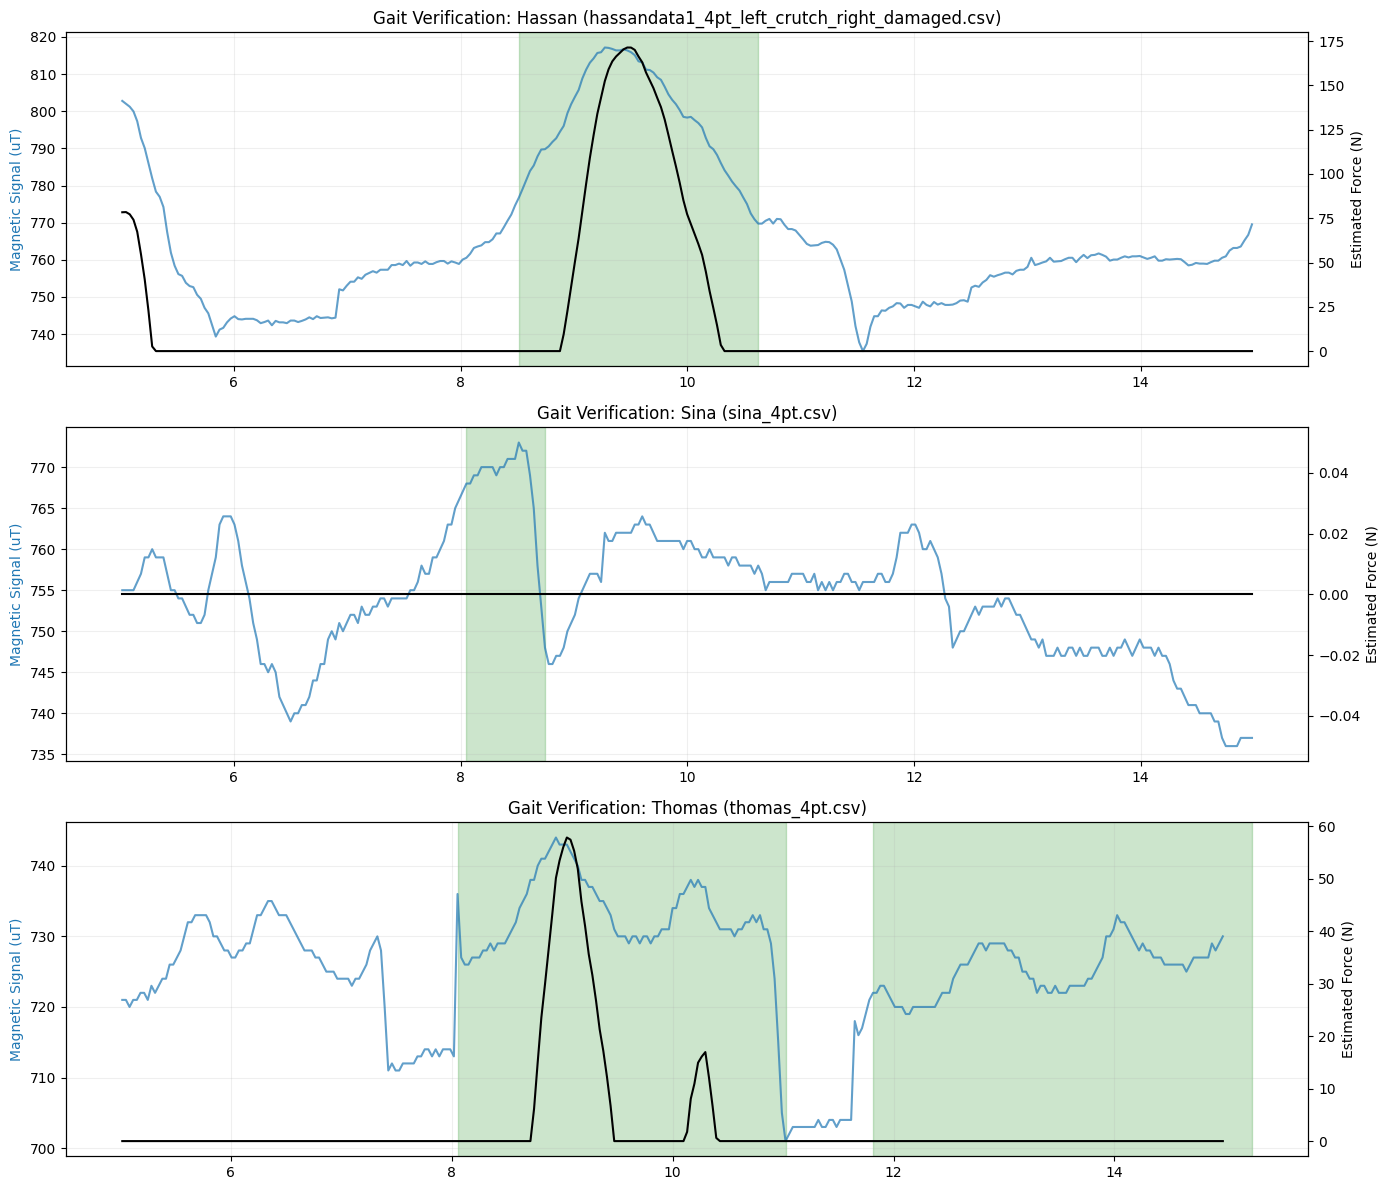

In [7]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# --- Constants required for the Rdiff pipeline ---
R_DIFF_ENTER_MM = 0.05
RELEASE_FRACTION = 0.2
REFRACTORY_MS = 100.0
RELEASE_CONFIRM_MS = 50.0
SUSTAINED_CUTOFF_S = 5.0

# Representative gait files for each person (excluding falls)
sample_files = {
    "Hassan": "hassandata1_4pt_left_crutch_right_damaged.csv",
    "Sina": "sina_4pt.csv",
    "Thomas": "thomas_4pt.csv"
}

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for i, (person, fname) in enumerate(sample_files.items()):
    path = Path(fname)
    if not path.exists():
        axs[i].text(0.5, 0.5, f"File {fname} not found", ha='center')
        continue

    # 1. Load and Process
    df_raw, _ = load_hassan_capture_csv(path)
    df_force, _ = add_force_columns(df_raw)
    # Now using the pipeline function defined in cell HMacdcN753GM
    df_det, df_ev = run_rdiff_pipeline(df_force)

    # 2. Zoom to a 10-second window (5s to 15s) for clear stride visualization
    t_start, t_end = 5.0, 15.0
    mask = (df_det['time_s'] >= t_start) & (df_det['time_s'] <= t_end)
    df_zoom = df_det[mask]

    # 3. Plot Signals
    ax_twin = axs[i].twinx()
    ln1 = axs[i].plot(df_zoom['time_s'], df_zoom['mz_uT'], color='C0', alpha=0.7, label='mz_uT (Mag)')
    ln2 = ax_twin.plot(df_zoom['time_s'], df_zoom['force_n'], color='black', lw=1.5, label='Force (N)')

    # 4. Overlay Stance Spans
    if not df_ev.empty:
        zoom_evs = df_ev[(df_ev['start_s'] >= t_start - 1) & (df_ev['release_s'] <= t_end + 1)]
        for _, ev in zoom_evs.iterrows():
            if ev['accepted']:
                color = 'green' if ev['kind'] == 'step' else 'orange'
                axs[i].axvspan(ev['start_s'], ev['release_s'], color=color, alpha=0.2)

    axs[i].set_title(f"Gait Verification: {person} ({fname})")
    axs[i].set_ylabel("Magnetic Signal (uT)", color='C0')
    ax_twin.set_ylabel("Estimated Force (N)", color='black')
    axs[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [11]:
def compare_pipelines_head_to_head():
    results = []
    for subject, fname in sample_files.items():
        path = Path(fname)
        if not path.exists(): continue

        # 1. Load Data
        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # 2. Run Magnetic Pipeline (using existing function or equivalent logic)
        # Note: run_peak_release_pipeline is our standard Z-score model
        _, ev_mag = run_peak_release_pipeline(df_force)

        # 3. Run r_diff Pipeline
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        # 4. Aggregate Metrics
        results.append({
            'Subject': subject,
            'Pipeline': 'Magnetic (Z=2.0)',
            'Steps': len(ev_mag[ev_mag['accepted'] & (ev_mag['kind'] == 'step')]),
            'Sustained': len(ev_mag[ev_mag['accepted'] & (ev_mag['kind'] == 'sustained')]),
            'Avg Duration (s)': ev_mag.loc[ev_mag['accepted'], 'duration_s'].mean() if not ev_mag.empty else 0
        })
        results.append({
            'Subject': subject,
            'Pipeline': 'Displacement (2mm)',
            'Steps': len(ev_rdiff[ev_rdiff['accepted'] & (ev_rdiff['kind'] == 'step')]),
            'Sustained': len(ev_rdiff[ev_rdiff['accepted'] & (ev_rdiff['kind'] == 'sustained')]),
            'Avg Duration (s)': ev_rdiff.loc[ev_rdiff['accepted'], 'duration_s'].mean() if not ev_rdiff.empty else 0
        })

    comparison_df = pd.DataFrame(results)
    display(comparison_df.pivot(index='Subject', columns='Pipeline', values=['Steps', 'Avg Duration (s)']))
    return comparison_df

comparison_results = compare_pipelines_head_to_head()

Steps                    Avg Duration (s)  \
Pipeline Displacement (2mm) Magnetic (Z=2.0) Displacement (2mm)   
Subject                                                           
Hassan                 10.0              9.0           1.395900   
Sina                    5.0             13.0           0.963600   
Thomas                  6.0              4.0           3.790875   

                           
Pipeline Magnetic (Z=2.0)  
Subject                    
Hassan           2.412667  
Sina             1.704214  
Thomas           3.751000

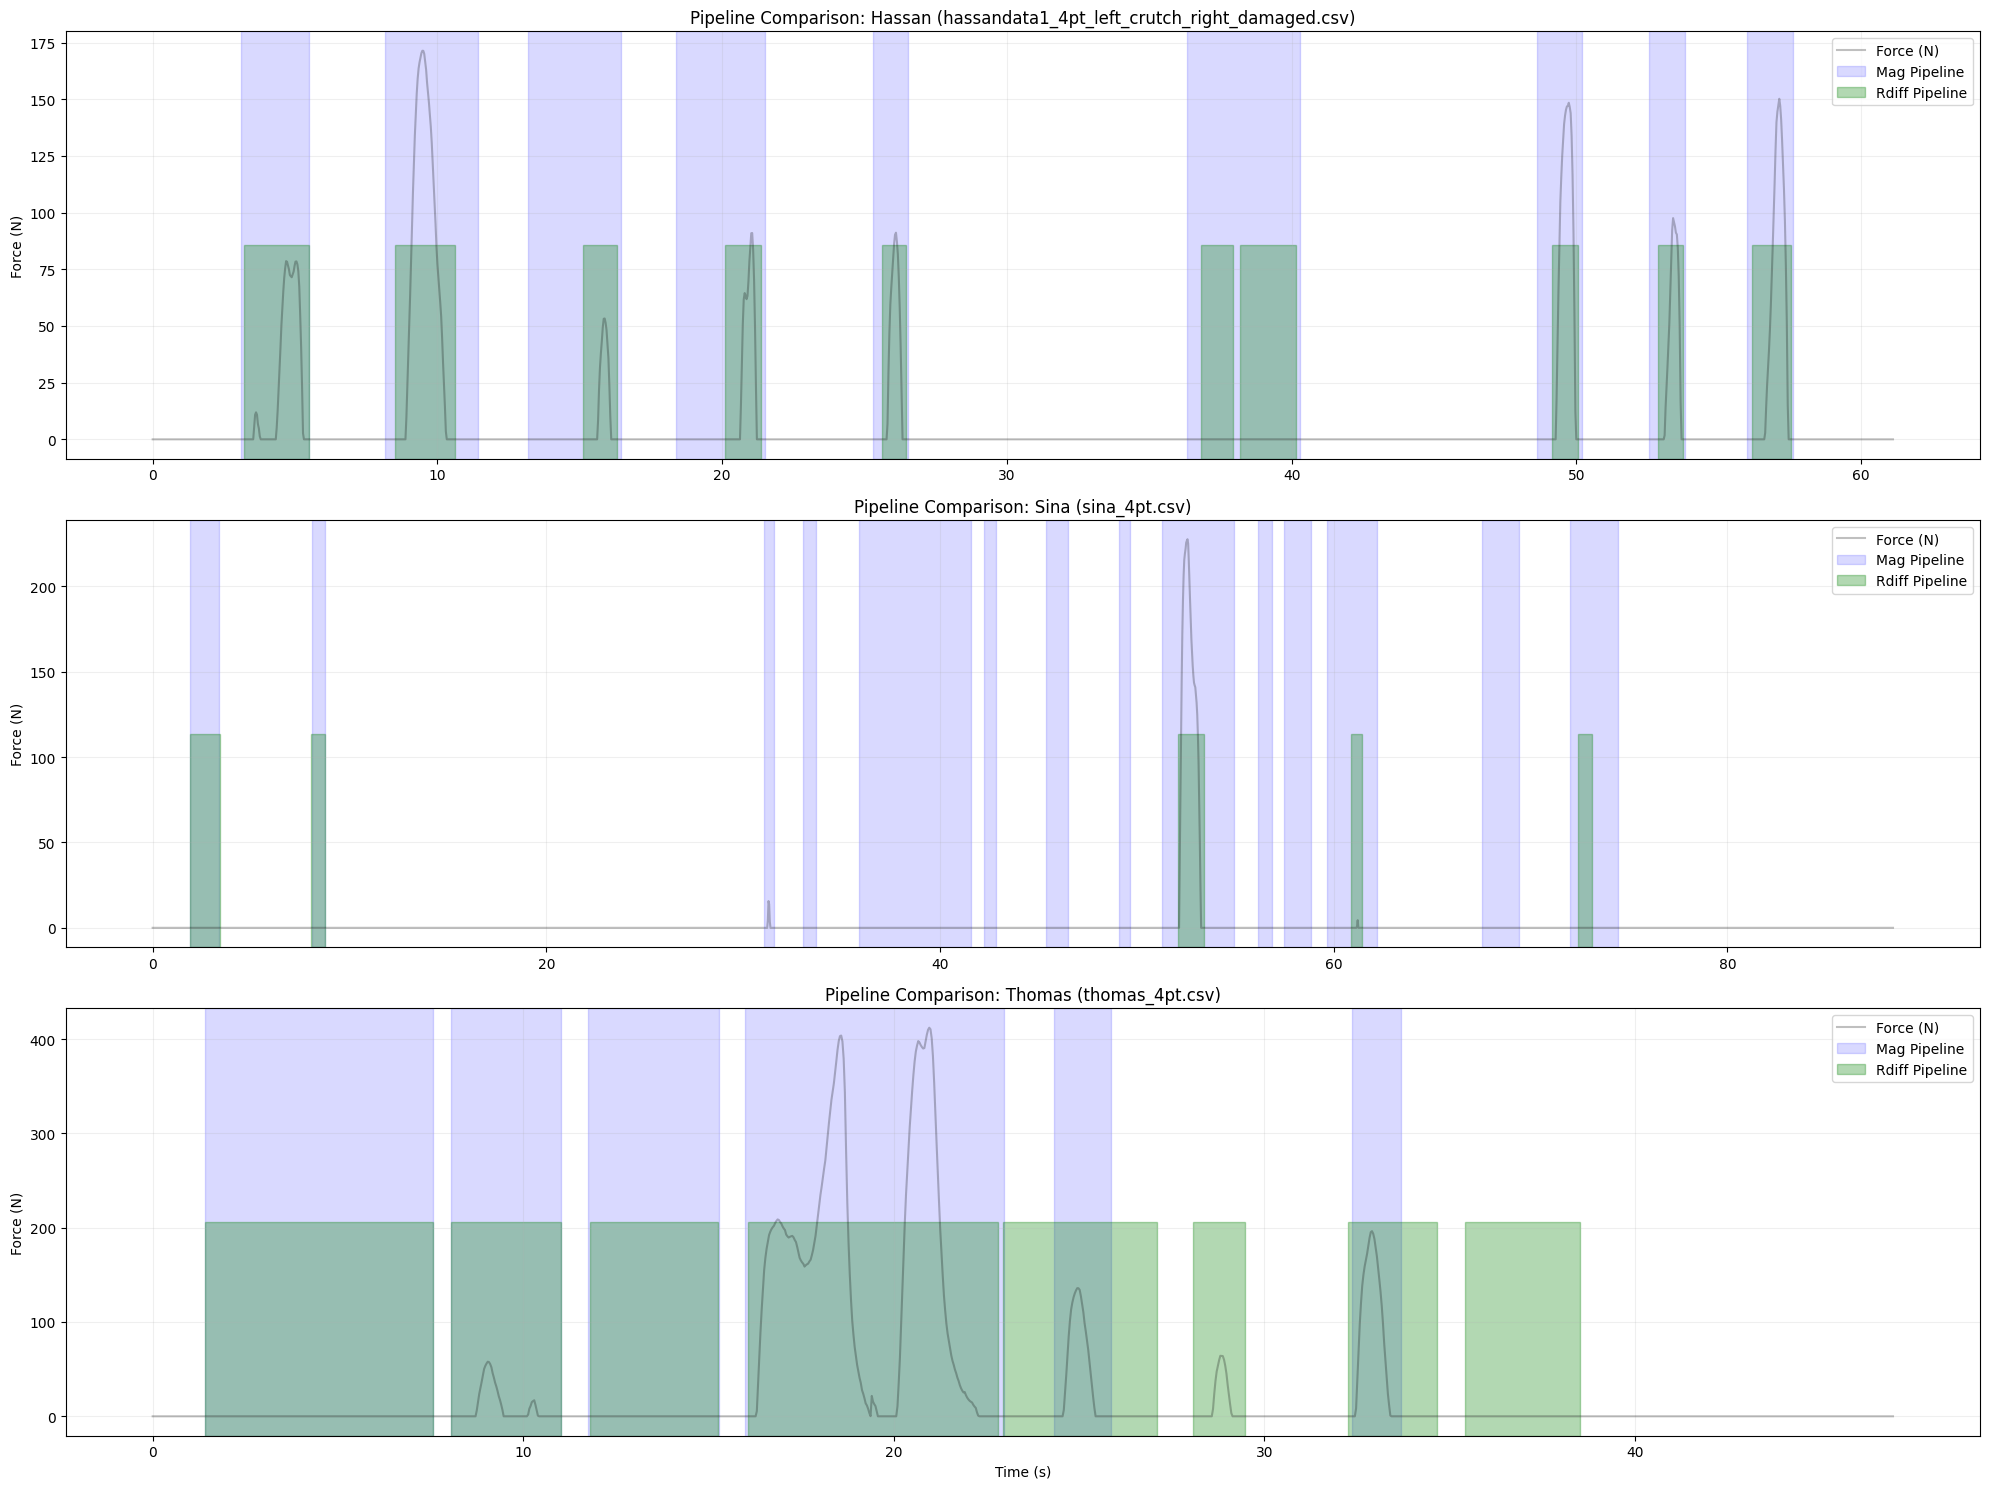

In [75]:
def plot_all_pipelines_comparison(subjects=["Hassan", "Sina", "Thomas"]):
    fig, axs = plt.subplots(len(subjects), 1, figsize=(20, 5 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        fname = sample_files[person]
        df_raw, _ = load_hassan_capture_csv(Path(fname))
        df_force, _ = add_force_columns(df_raw)

        # Run both pipelines
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        t = df_force['time_s']
        axs[i].plot(t, df_force['force_n'], color='black', alpha=0.25, label='Force (N)')

        # Overlay Magnetic (Blue)
        first_mag = True
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.15,
                           label='Mag Pipeline' if first_mag else "")
            first_mag = False

        # Overlay Rdiff (Green)
        first_rdiff = True
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.3,
                           label='Rdiff Pipeline' if first_rdiff else "")
            first_rdiff = False

        axs[i].set_title(f"Pipeline Comparison: {person} ({fname})")
        axs[i].set_ylabel("Force (N)")
        axs[i].legend(loc='upper right')
        axs[i].grid(True, alpha=0.2)

    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_all_pipelines_comparison()

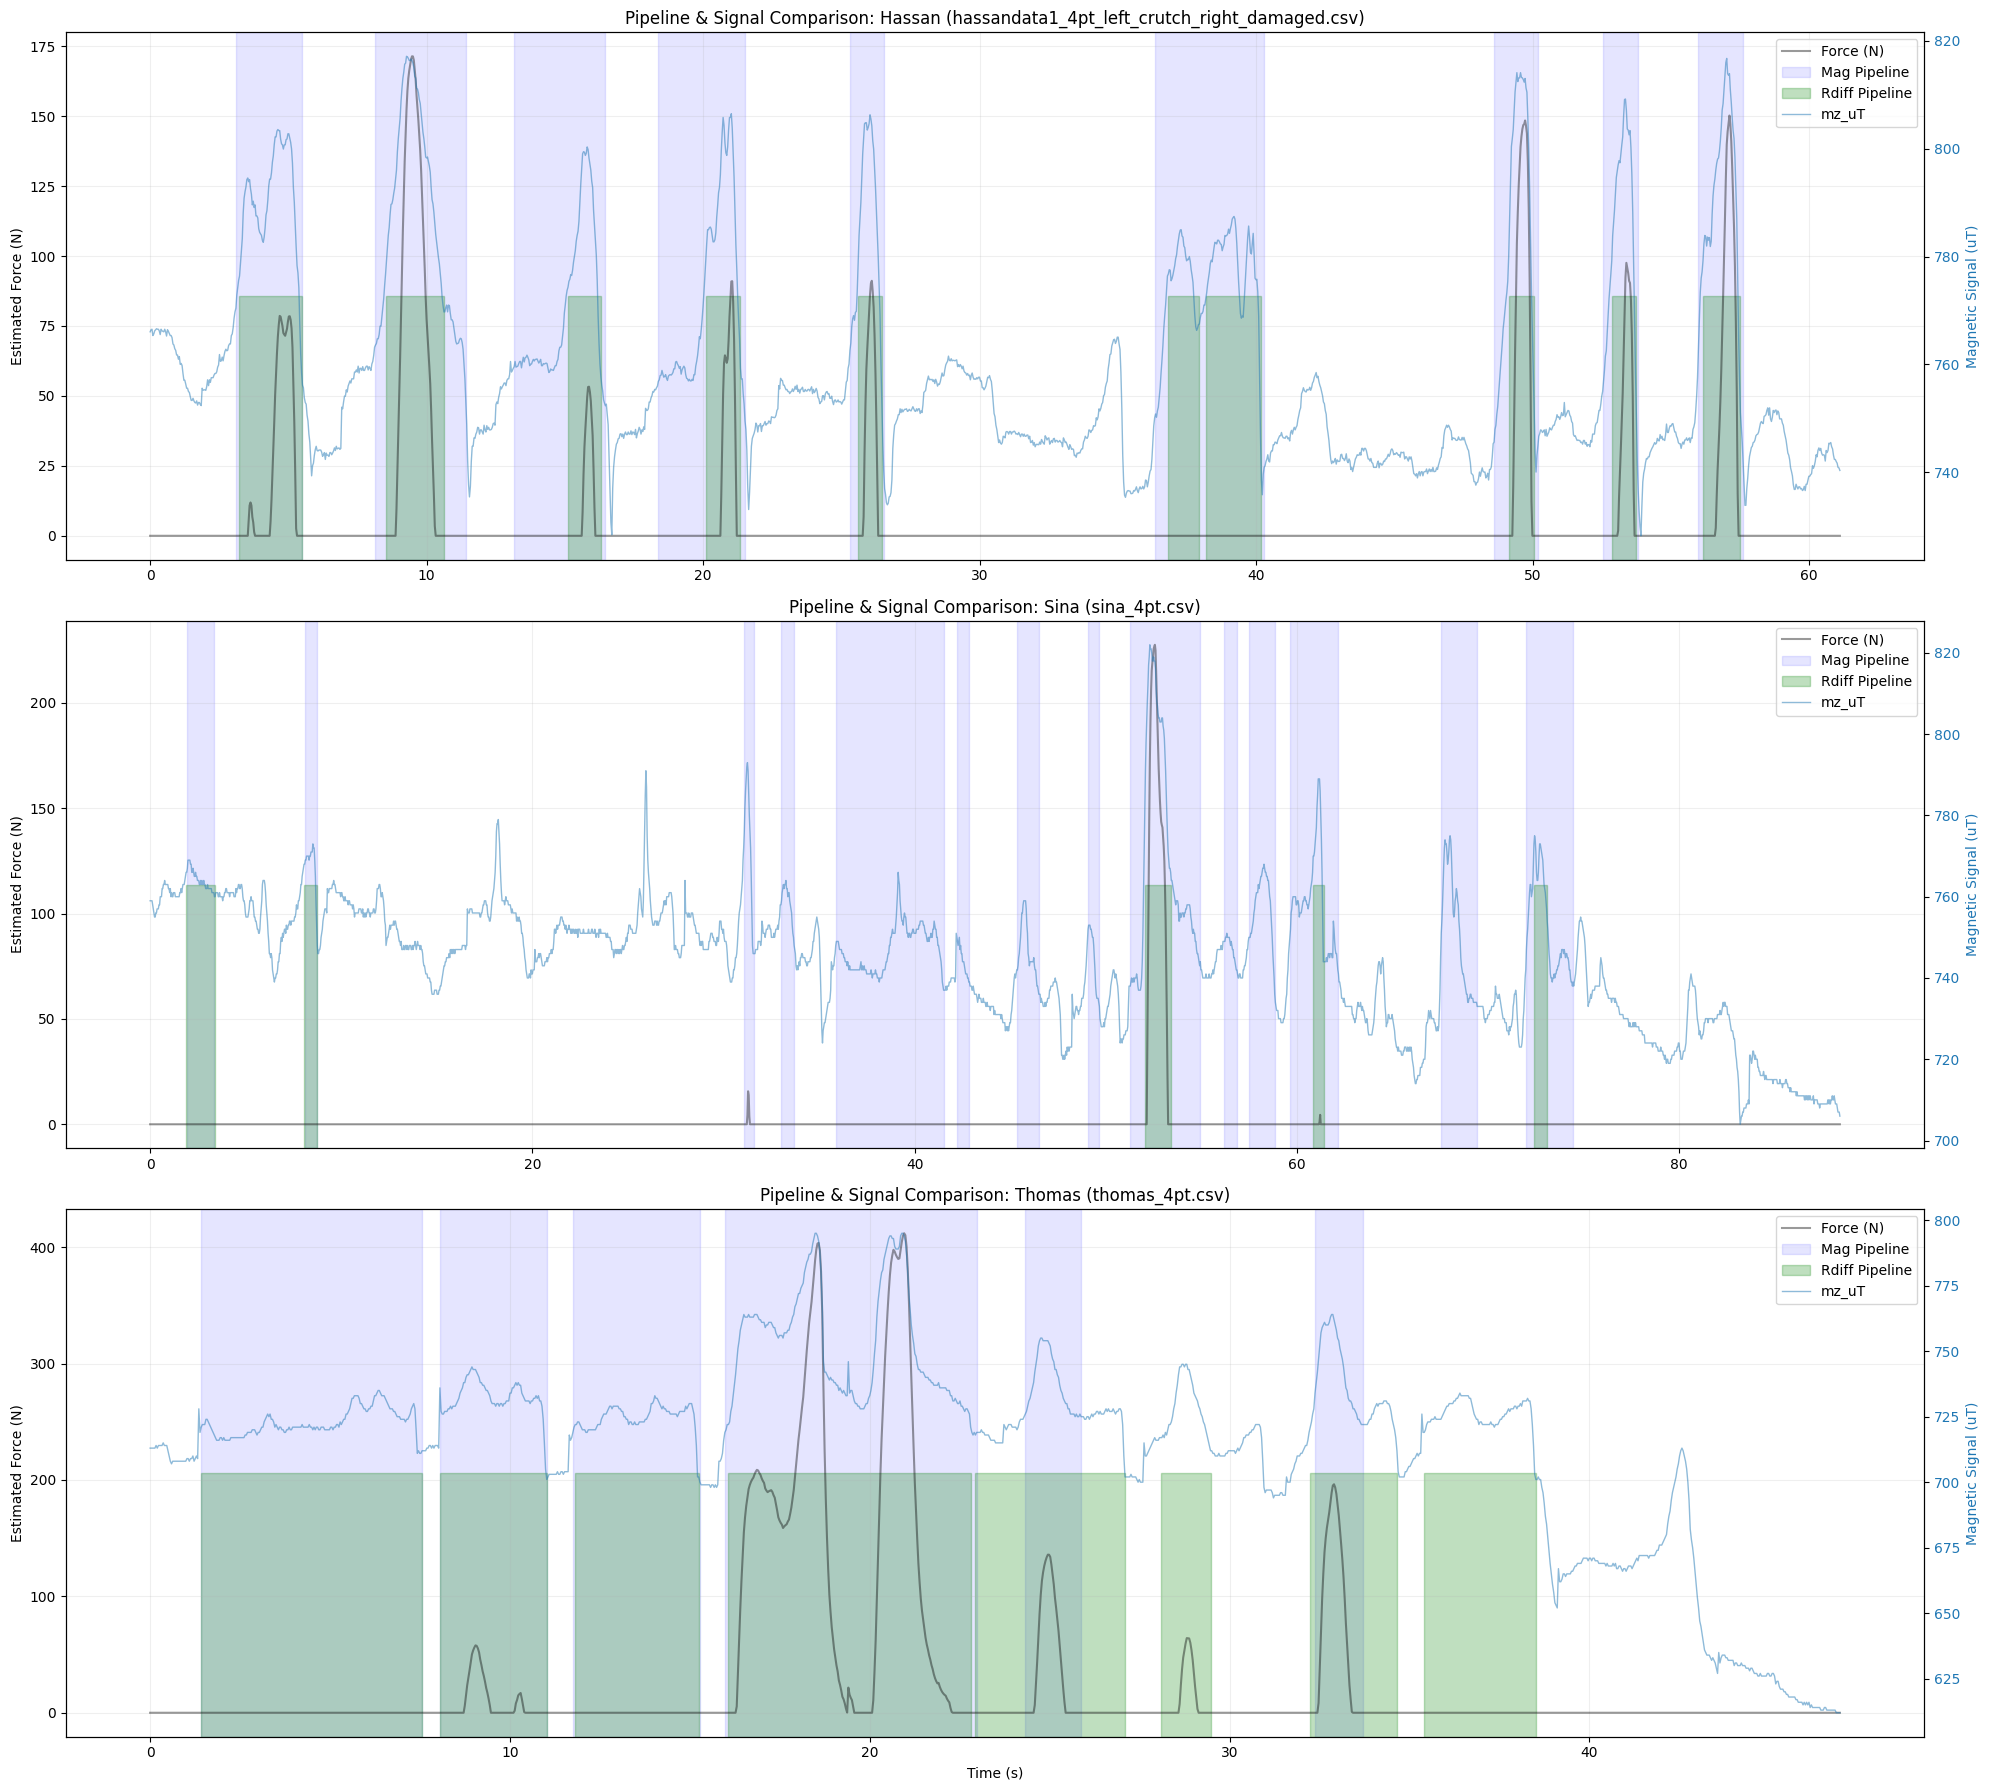

In [78]:
def plot_all_pipelines_comparison_with_mz(subjects=["Hassan", "Sina", "Thomas"]):
    fig, axs = plt.subplots(len(subjects), 1, figsize=(20, 6 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        fname = sample_files[person]
        df_raw, _ = load_hassan_capture_csv(Path(fname))
        df_force, _ = add_force_columns(df_raw)

        # Run both pipelines
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        t = df_force['time_s']

        # Primary Axis: Force
        axs[i].plot(t, df_force['force_n'], color='black', alpha=0.4, lw=1.5, label='Force (N)')

        # Secondary Axis: Magnetic Signal (mz)
        ax_mag = axs[i].twinx()
        ax_mag.plot(t, df_force['mz_uT'], color='C0', alpha=0.5, lw=1, label='mz_uT')
        ax_mag.set_ylabel("Magnetic Signal (uT)", color='C0')
        ax_mag.tick_params(axis='y', labelcolor='C0')

        # Overlay Magnetic Spans (Blue)
        first_mag = True
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.1,
                           label='Mag Pipeline' if first_mag else "")
            first_mag = False

        # Overlay Rdiff Spans (Green)
        first_rdiff = True
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.25,
                           label='Rdiff Pipeline' if first_rdiff else "")
            first_rdiff = False

        axs[i].set_title(f"Pipeline & Signal Comparison: {person} ({fname})")
        axs[i].set_ylabel("Estimated Force (N)")

        # Combine legends from both axes
        lines, labels = axs[i].get_legend_handles_labels()
        lines2, labels2 = ax_mag.get_legend_handles_labels()
        axs[i].legend(lines + lines2, labels + labels2, loc='upper right')
        axs[i].grid(True, alpha=0.2)

    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_all_pipelines_comparison_with_mz()

In [86]:
def compare_three_pipelines_head_to_head():
    results = []
    for subject, fname in sample_files.items():
        path = Path(fname)
        if not path.exists(): continue

        # 1. Load and prepare data
        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # 2. Run All Three Pipelines
        _, ev_mag = run_peak_release_pipeline(df_force) # Hard Z=2.0
        _, ev_rdiff = run_rdiff_pipeline(df_force)      # Displacement 2mm
        _, ev_corr = corroborated_pipeline(df_force)    # Soft Z=1.0 + Sensor Corr

        pipelines = [
            ('Magnetic (Z=2.0)', ev_mag),
            ('Displacement (2mm)', ev_rdiff),
            ('Corroborated (Z=1.0+Sens)', ev_corr)
        ]

        for name, ev_df in pipelines:
            results.append({
                'Subject': subject,
                'Pipeline': name,
                'Steps': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'step')]) if not ev_df.empty else 0,
                'Sustained': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'sustained')]) if not ev_df.empty else 0,
                'Avg Duration (s)': ev_df.loc[ev_df['accepted'], 'duration_s'].mean() if not ev_df.empty else 0
            })

    comparison_df = pd.DataFrame(results)
    # Pivot for clean comparison
    table = comparison_df.pivot(index='Subject', columns='Pipeline', values='Steps')
    display(table)
    return comparison_df

comparison_3_results = compare_three_pipelines_head_to_head()

Pipeline,Corroborated (Z=1.0+Sens),Displacement (2mm),Magnetic (Z=2.0)
Subject,,,
Hassan,9,10,9
Sina,18,5,13
Thomas,5,6,4


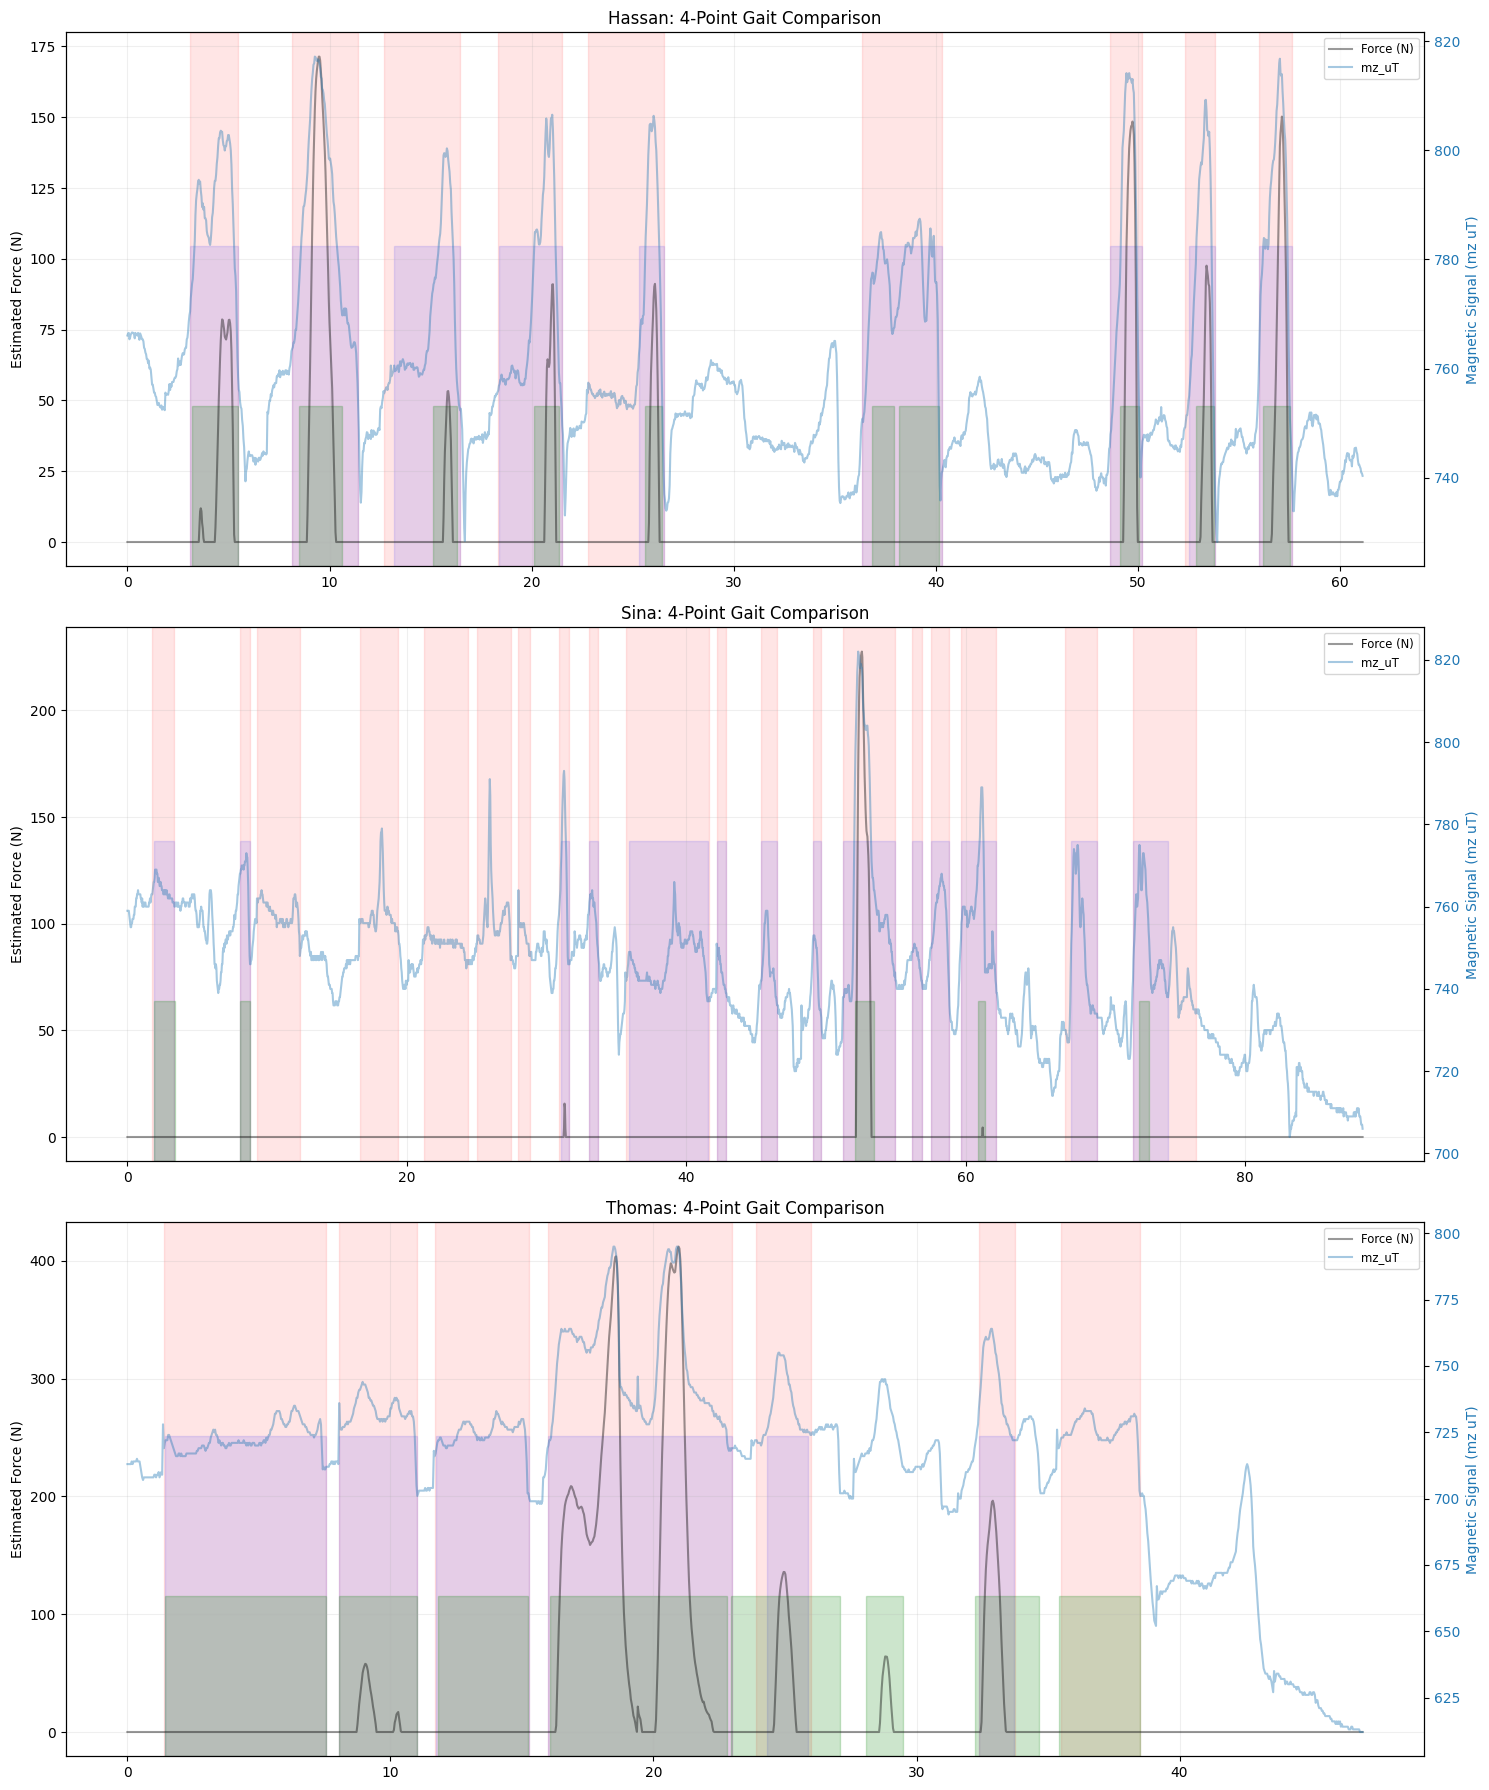

In [14]:
def plot_4pt_comparison_with_mz():
    subjects = ["Hassan", "Sina", "Thomas"]
    fig, axs = plt.subplots(len(subjects), 1, figsize=(15, 6 * len(subjects)), sharex=False)

    for i, person in enumerate(subjects):
        # Find the 4pt file for this subject
        match_file = None
        for fname, (p, g) in subject_registry.items():
            if p == person and g == "4pt":
                match_file = fname
                break

        if not match_file or not Path(match_file).exists():
            axs[i].text(0.5, 0.5, f"No 4pt file for {person}", ha='center')
            continue

        # Load and process
        df_raw, _ = load_hassan_capture_csv(Path(match_file))
        df_force, _ = add_force_columns(df_raw)

        # Run Pipelines
        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)
        _, ev_corr = corroborated_pipeline(df_force)

        t = df_force['time_s']

        # Primary Axis: Force
        ln1 = axs[i].plot(t, df_force['force_n'], color='black', alpha=0.4, lw=1.5, label='Force (N)')
        axs[i].set_ylabel("Estimated Force (N)", color='black')

        # Secondary Axis: Magnetic Signal
        ax_mag = axs[i].twinx()
        ln2 = ax_mag.plot(t, df_force['mz_uT'], color='C0', alpha=0.4, label='mz_uT')
        ax_mag.set_ylabel("Magnetic Signal (mz uT)", color='C0')
        ax_mag.tick_params(axis='y', labelcolor='C0')

        # Overlay Spans
        # Corroborated (Top level - Red)
        for _, ev in ev_corr[ev_corr['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='red', alpha=0.1, label='Corr' if _ == 0 else "")

        # Magnetic (Mid level - Blue)
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.6, color='blue', alpha=0.1, label='Mag' if _ == 0 else "")

        # Displacement (Bottom level - Green)
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.3, color='green', alpha=0.2, label='Rdiff' if _ == 0 else "")

        axs[i].set_title(f"{person}: 4-Point Gait Comparison")
        axs[i].grid(True, alpha=0.2)

        # Combined Legend
        lines = ln1 + ln2
        labels = [l.get_label() for l in lines]
        axs[i].legend(lines, labels, loc='upper right', fontsize='small')

    plt.tight_layout()
    plt.show()

plot_4pt_comparison_with_mz()

In [79]:
def compare_all_gait_types():
    results = []
    # Iterate through the full registry to cover all gait types
    for filename, (person, gait) in subject_registry.items():
        path = Path(filename)
        if not path.exists() or gait == 'fall': continue

        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        # Run Magnetic Pipeline
        _, ev_mag = run_peak_release_pipeline(df_force)
        # Run Displacement Pipeline
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        for pipe_name, ev_df in [('Magnetic', ev_mag), ('Displacement', ev_rdiff)]:
            results.append({
                'Subject': person,
                'Gait': gait,
                'Pipeline': pipe_name,
                'Steps Detected': len(ev_df[ev_df['accepted'] & (ev_df['kind'] == 'step')]) if not ev_df.empty else 0,
                'Avg Duration': ev_df.loc[ev_df['accepted'], 'duration_s'].mean() if not ev_df.empty else 0
            })

    all_gaits_df = pd.DataFrame(results)
    # Pivot for a clear comparison table
    comparison_table = all_gaits_df.pivot_table(
        index=['Subject', 'Gait'],
        columns='Pipeline',
        values='Steps Detected',
        fill_value=0
    )
    display(comparison_table)
    return all_gaits_df

all_gaits_comparison = compare_all_gait_types()

Pipeline       Displacement  Magnetic
Subject Gait                         
Hassan  2pt             9.0      10.0
        3pt            11.0      15.0
        4pt            10.0       9.0
        swing          13.0      12.0
Sina    2pt            16.0      13.0
        3pt            33.0      27.0
        4pt             5.0      13.0
        swing           6.0      15.0
Thomas  2pt            17.0      15.0
        3pt            34.0      25.0
        4pt             6.0       4.0
        swing           0.0      13.0

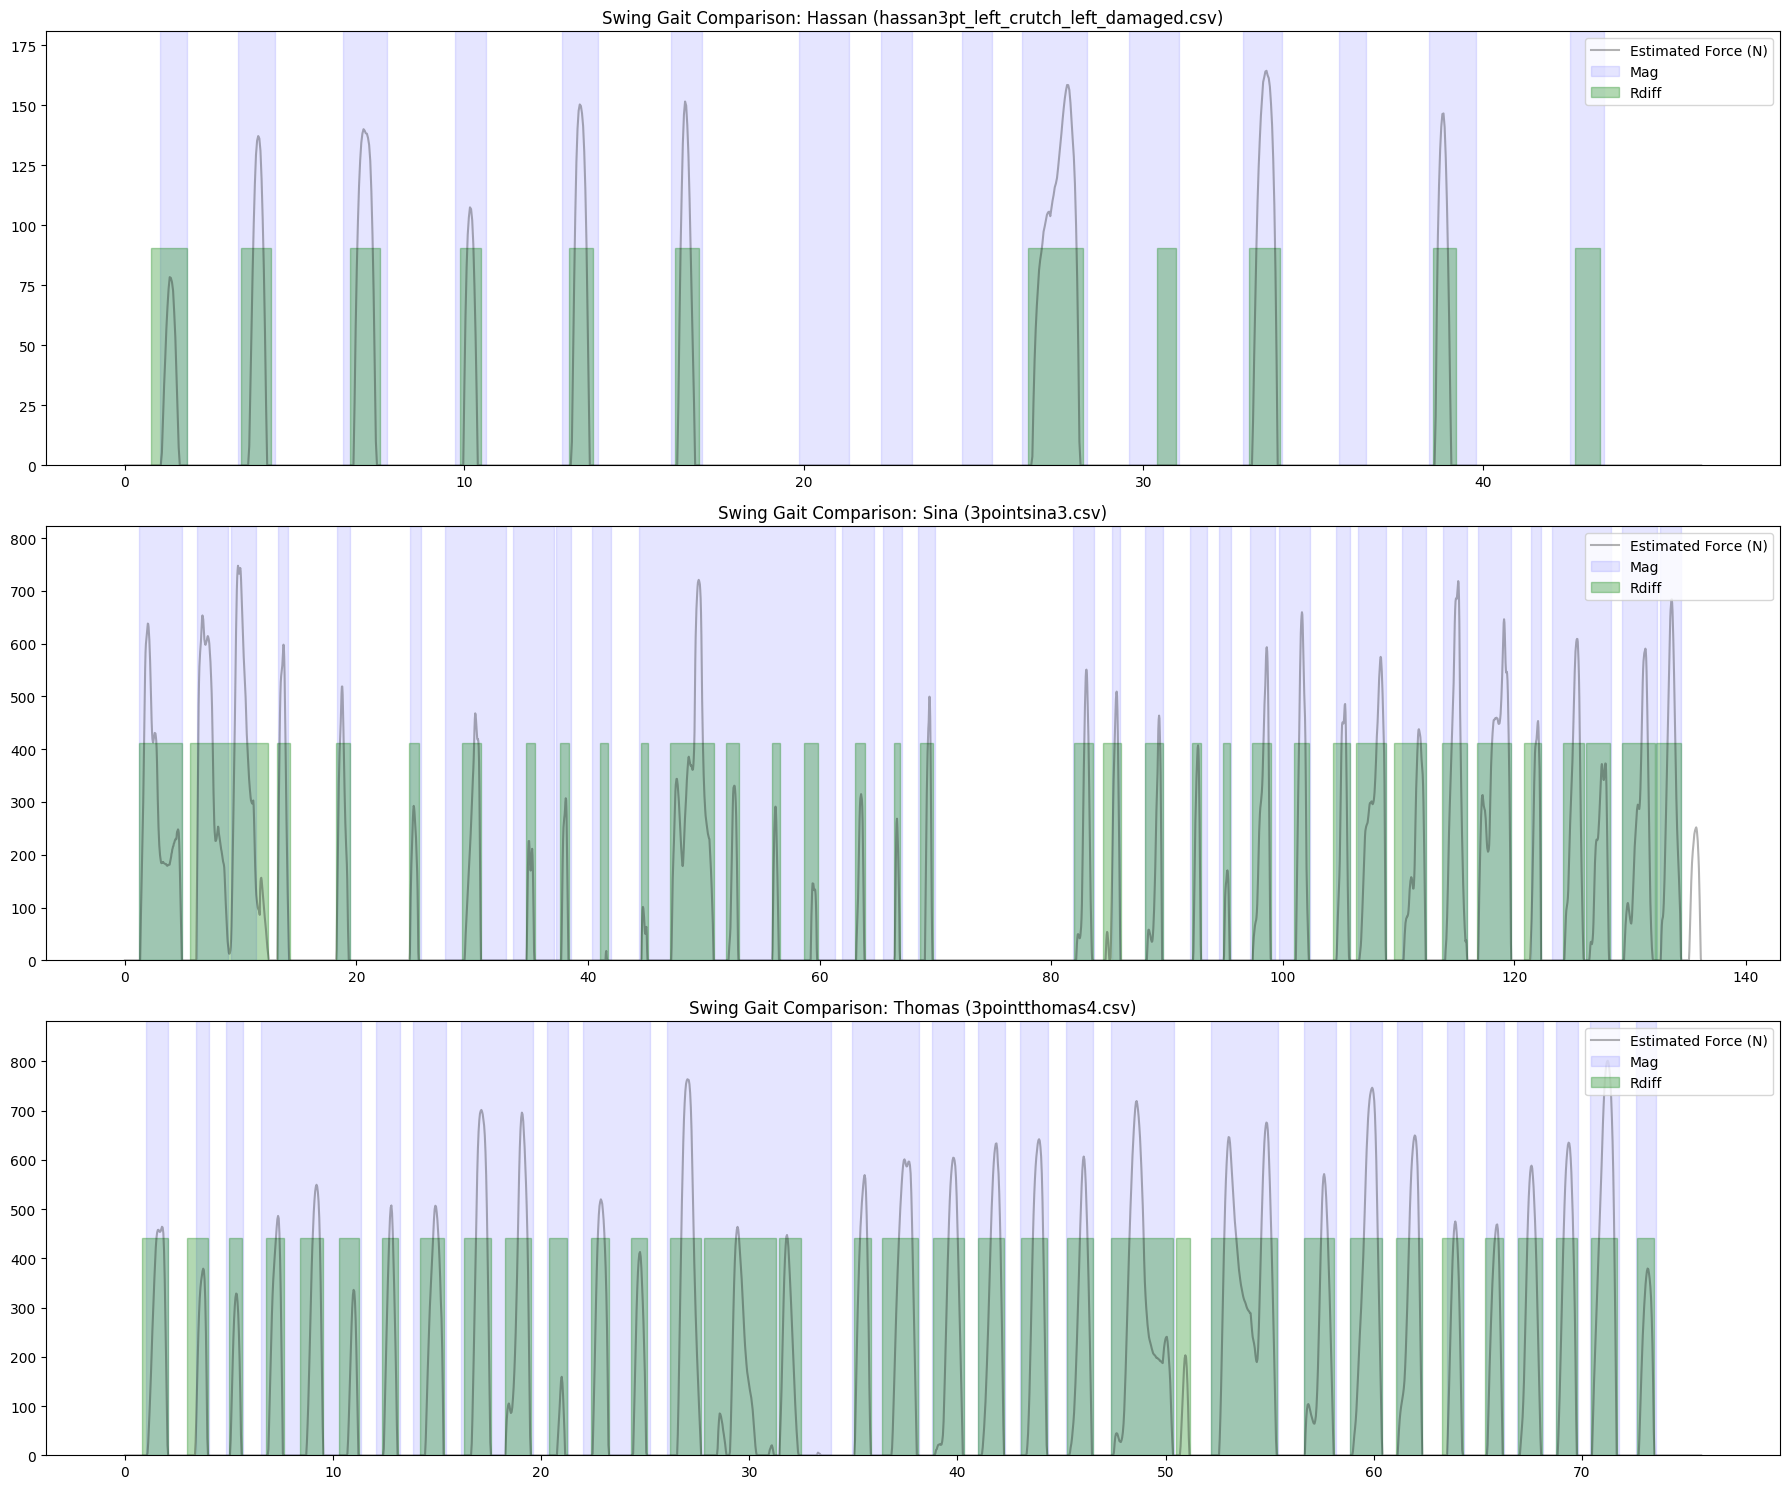

In [80]:
def plot_swing_gait_comparison():
    swing_files = {
        "Hassan": "hassan3pt_left_crutch_left_damaged.csv",
        "Sina": "3pointsina3.csv",
        "Thomas": "3pointthomas4.csv"
    }

    fig, axs = plt.subplots(3, 1, figsize=(18, 15))

    for i, (person, fname) in enumerate(swing_files.items()):
        path = Path(fname)
        if not path.exists():
            axs[i].set_title(f"{person}: {fname} not found")
            continue

        df_raw, _ = load_hassan_capture_csv(path)
        df_force, _ = add_force_columns(df_raw)

        _, ev_mag = run_peak_release_pipeline(df_force)
        _, ev_rdiff = run_rdiff_pipeline(df_force)

        t = df_force['time_s']
        axs[i].plot(t, df_force['force_n'], color='black', alpha=0.3, label='Estimated Force (N)')

        # Mag Spans
        for _, ev in ev_mag[ev_mag['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], color='blue', alpha=0.1, label='Mag' if _ == ev_mag[ev_mag['accepted']].index[0] else "")

        # Rdiff Spans
        for _, ev in ev_rdiff[ev_rdiff['accepted']].iterrows():
            axs[i].axvspan(ev['start_s'], ev['release_s'], ymin=0, ymax=0.5, color='green', alpha=0.3, label='Rdiff' if _ == ev_rdiff[ev_rdiff['accepted']].index[0] else "")

        axs[i].set_title(f"Swing Gait Comparison: {person} ({fname})")
        axs[i].legend(loc='upper right')
        axs[i].set_ylim(0, df_force['force_n'].max() * 1.1)

    plt.tight_layout()
    plt.show()

plot_swing_gait_comparison()

Meta Model

In [83]:
def export_sensor_master_no_detection():
    """
    Aggregates sensor and force data for Hassan, Sina, and Thomas.
    Includes 'fall' gait. Excludes all detection/stance/z-score columns.
    """
    master_rows = []

    for filename, (person, gait) in subject_registry.items():
        path = Path(filename)
        if not path.exists():
            continue

        # 1. Load data using the established helper
        raw_df, _ = load_hassan_capture_csv(path)
        if raw_df.empty:
            continue

        # 2. Handle specific column mapping for Thomas/Sina fall files if needed
        if filename in ["tgfall.csv", "tgfall2.csv"]:
            raw_df["mz_uT"] = raw_df.iloc[:, -1]

        # 3. Add Force Estimates (adds r_diff and force_n)
        force_df, _ = add_force_columns(raw_df)

        # 4. Label the data
        force_df['person_id'] = person
        force_df['gait_type'] = gait

        # 5. Define the clean column set (NO step detection columns like 'is_stance', 'state', 'z_score')
        sensor_cols = [
            'person_id', 'gait_type', 'time_s', 'force_n', 'r_diff_mm',
            'ax_g', 'ay_g', 'az_g', 'gx_dps', 'gy_dps', 'gz_dps',
            'mx_uT', 'my_uT', 'mz_uT', 'roll_deg', 'pitch_deg', 'yaw_deg'
        ]

        # Only keep existing columns from the list
        existing_cols = [c for c in sensor_cols if c in force_df.columns]
        master_rows.append(force_df[existing_cols])

    # Combine all into one master table
    sensor_master_df = pd.concat(master_rows, ignore_index=True)

    # Save to CSV
    sensor_master_df.to_csv("sensor_only_master.csv", index=False)
    print(f"Success! Created master dataset with {len(sensor_master_df)} rows.")
    return sensor_master_df

# Run the function and show summary
sensor_data_df = export_sensor_master_no_detection()
display(sensor_data_df.head())
display(sensor_data_df.groupby(['person_id', 'gait_type']).size().unstack(fill_value=0))

Success! Created master dataset with 22293 rows.


,person_id,gait_type,time_s,force_n,r_diff_mm,ax_g,ay_g,az_g,gx_dps,gy_dps,gz_dps,mx_uT,my_uT,mz_uT,roll_deg,pitch_deg,yaw_deg
0,Hassan,swing,0.000,0.0,0.044495,-0.9941,-0.1259,0.0239,-0.98,-0.35,1.82,104.69,3.26,732.26,-130.64,85.90,121.33
1,Hassan,swing,0.033,0.0,0.043160,-0.9955,-0.1264,0.0205,-0.49,-0.70,2.03,104.69,3.26,731.79,-126.74,85.92,125.24
2,Hassan,swing,0.066,0.0,0.041903,-0.9945,-0.1220,0.0234,-0.91,-0.70,2.17,105.05,2.90,731.70,-122.88,85.94,129.12
3,Hassan,swing,0.099,0.0,0.040960,-0.9975,-0.1274,0.0259,0.28,-0.70,2.10,104.32,3.26,731.70,-118.94,85.93,133.04
4,Hassan,swing,0.132,0.0,0.040253,-0.9960,-0.1249,0.0283,3.92,-0.56,1.82,104.68,3.26,731.70,-114.91,85.90,136.92


gait_type,2pt,3pt,4pt,fall,swing
person_id,,,,,
Hassan,1101,1408,1853,0,952
Sina,1961,4127,2680,0,1549
Thomas,1318,2296,1424,452,1172
